In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Acquiring the data files

In [3]:
train_df = pd.read_csv("/kaggle/input/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/titanic/test.csv")
# gender_submission = pd.read_csv("/kaggle/input/titanic/gender_submission.csv")

In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Describe the data

In [6]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## Which Features has most likely has relationship to Survived?

- Do Age matter? Which one kids, youth, old survived most?
- Does it matter which ticket class did passenger have for their survival?
- Does survived is affected by person being male or female?
- Does survived is affected if a person had a spouse or siblings on board?
- Does survived is affected if a person had chlidren or parents on board?
- Does survived is affected by the amount of Fare person paid?
- Does cabin number matter in survival of passenger?
- Does Port of embarkation from where a passenger embarked influences survival of passenger?

## Null values found in features: 'Age', 'Fare', 'Cabin'

In [8]:
print("Training model data")
for ft in train_df.columns:
    null_val = train_df[ft].isnull().sum()
    s = train_df[ft].size
    print(f"Null values in {ft} are ", (null_val/s)*100)
    
print('==' * 50)

print("Testing model data")
for ft in test_df.columns:
    null_val = test_df[ft].isnull().sum()
    s = test_df[ft].size
    print(f"Null values in {ft} are ", (null_val/s)*100)

Training model data
Null values in PassengerId are  0.0
Null values in Survived are  0.0
Null values in Pclass are  0.0
Null values in Name are  0.0
Null values in Sex are  0.0
Null values in Age are  19.865319865319865
Null values in SibSp are  0.0
Null values in Parch are  0.0
Null values in Ticket are  0.0
Null values in Fare are  0.0
Null values in Cabin are  77.10437710437711
Null values in Embarked are  0.22446689113355783
Testing model data
Null values in PassengerId are  0.0
Null values in Pclass are  0.0
Null values in Name are  0.0
Null values in Sex are  0.0
Null values in Age are  20.574162679425836
Null values in SibSp are  0.0
Null values in Parch are  0.0
Null values in Ticket are  0.0
Null values in Fare are  0.23923444976076555
Null values in Cabin are  78.22966507177034
Null values in Embarked are  0.0


## Dropping the Cabin ~ 78% null values

In [9]:
train_df.drop('Cabin', axis= 1, inplace=True)
test_df.drop('Cabin', axis= 1, inplace=True)

## Filling Age feature na with median value

In [10]:
print("Median of Age = ", train_df['Age'].median())
print("Mode of Age = ", train_df['Age'].mode())
print("Mode of Age = ", train_df.Age.mean())

Median of Age =  28.0
Mode of Age =  0    24.0
dtype: float64
Mode of Age =  29.69911764705882


In [11]:
train_df['Age'].fillna(28, inplace=True)

In [12]:
print("Median of Age = ", test_df['Age'].median())
print("Mode of Age = ", test_df['Age'].mode())
print("mean of Age = ", test_df.Age.mean())

Median of Age =  27.0
Mode of Age =  0    21.0
1    24.0
dtype: float64
mean of Age =  30.272590361445783


In [13]:
test_df['Age'].fillna(28, inplace=True)

## filling Embarked with median of Embarked

In [14]:
print(train_df['Embarked'].value_counts())
print('mode of Embarked = ', train_df['Embarked'].mode())

S    644
C    168
Q     77
Name: Embarked, dtype: int64
mode of Embarked =  0    S
dtype: object


In [15]:
train_df['Embarked'].fillna('S', inplace=True)

## Fill na of 'Fare' 

In [16]:
print("Median of Fare = ", train_df['Fare'].median())
print("Mode of Fare = ", train_df['Fare'].mode())
print("Mean of Fare = ", train_df['Fare'].mean())

Median of Fare =  14.4542
Mode of Fare =  0    8.05
dtype: float64
Mean of Fare =  32.2042079685746


In [17]:
test_df['Fare'].fillna(14.50, inplace=True)

# Dropping 'passengerid' and 'name' and 'Ticket' - has no relation to survived

In [18]:
train_df.drop(['PassengerId', 'Name'], axis=1, inplace=True)
test_df.drop(['Name'], axis=1, inplace=True)

In [19]:
train_df.drop('Ticket', axis=1, inplace=True)
test_df.drop('Ticket', axis=1, inplace=True)

# Analyzing the relationship between survived, Pclass, SibSp, Sex, Parch

- Passengers travelling alone has more probability of surviving and
- Female passengers had high probability of surviving
- SibSp and Parch has no direct relationship with survival, need to derive another feature from these 2.

In [20]:
variables = ['Pclass','SibSp','Sex','Parch']

for v in variables:
    print(train_df[[v, 'Survived']].groupby(v, as_index=False).mean().sort_values(by = 'Survived', ascending= False))
    print('=='*30)

   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
   SibSp  Survived
1      1  0.535885
2      2  0.464286
0      0  0.345395
3      3  0.250000
4      4  0.166667
5      5  0.000000
6      8  0.000000
      Sex  Survived
0  female  0.742038
1    male  0.188908
   Parch  Survived
3      3  0.600000
1      1  0.550847
2      2  0.500000
0      0  0.343658
5      5  0.200000
4      4  0.000000
6      6  0.000000


# Analyze by visualization

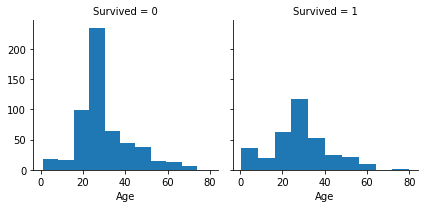

In [21]:
g = sns.FacetGrid(train_df, col= 'Survived')
g.map(plt.hist, 'Age',)

**Infants in Pclass= 2, Pclass=3 mostly survived**
**Most passengers in Pclass=1 survived**


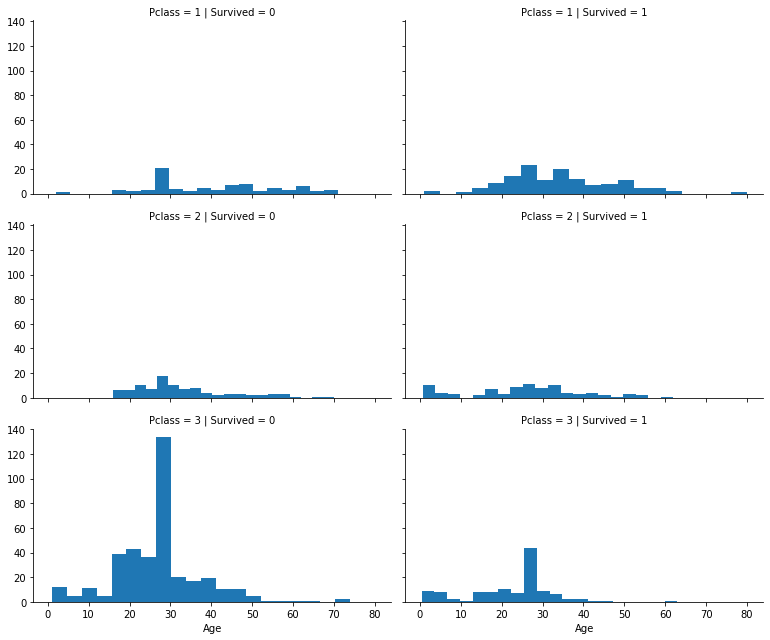

In [22]:
grid = sns.FacetGrid(train_df, col='Survived', row='Pclass', aspect=1.8)
grid.map(plt.hist, 'Age', bins=20)

In [23]:
sex = {'male':0, 'female':1}
train_df['Sex'] = train_df['Sex'].map(sex, )
test_df['Sex']=test_df['Sex'].map(sex,)

**Observations.**

- Higher fare paying passengers had better survival.
- Port of embarkation correlates with survival rates.
- Female passengers had much better survival rate than males.
- Exception in Embarked=C where males had higher survival rate. This could be a correlation between Pclass and Embarked and in turn Pclass and Survived, not necessarily direct correlation between Embarked and Survived.
- Males had better survival rate in Pclass=3 when compared with Pclass=2 for C and Q ports.
- Ports of embarkation have varying survival rates for Pclass=3 and among male passengers.

/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:670: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:675: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


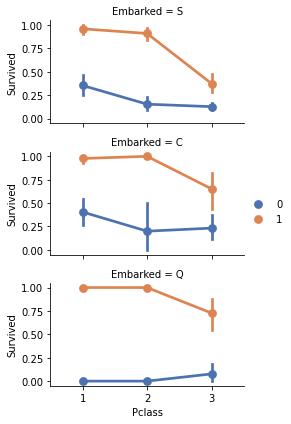

In [24]:
grid = sns.FacetGrid(train_df, row='Embarked', aspect = 1.8, height = 2)
grid.map(sns.pointplot, 'Pclass','Survived','Sex', palette='deep')
grid.add_legend()

/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:670: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


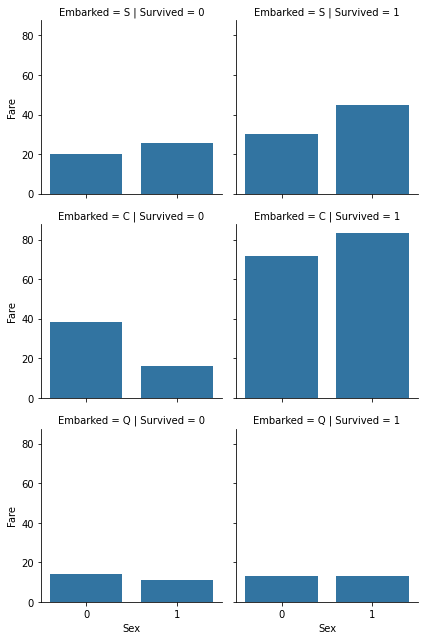

In [25]:
grid = sns.FacetGrid(train_df, row='Embarked',col='Survived', aspect= 1)
grid.map(sns.barplot, 'Sex','Fare',ci=None)

## Creating new feature 'age_band'

In [26]:
train_df['age_band'] = pd.cut(train_df['Age'], 5)
test_df['age_band'] = pd.cut(train_df['Age'], 5)

In [27]:
train_df[['age_band','Survived']].groupby(['age_band'], as_index=False).mean().sort_values(by='age_band')

,age_band,Survived
0,"(0.34, 16.336]",0.550000
1,"(16.336, 32.252]",0.344168
2,"(32.252, 48.168]",0.404255
3,"(48.168, 64.084]",0.434783
4,"(64.084, 80.0]",0.090909


Converting categorical data to ordinal data

In [28]:
combine = [train_df, test_df]
for dataset in combine:
    dataset.loc[ dataset['Age'] <= 16, 'Age' ]= 0
    dataset.loc[ (dataset['Age'] > 16) & (dataset['Age'] <=32), 'Age'] = 1
    dataset.loc[ (dataset['Age'] > 32) & (dataset['Age'] <=48), 'Age'] = 2
    dataset.loc[ (dataset['Age'] > 48) & (dataset['Age'] <=64), 'Age'] = 3
    dataset.loc[ (dataset['Age'] > 64), 'Age']= 4

In [29]:
train_df['Age']=train_df['Age'].astype('int32')
test_df['Age']= test_df['Age'].astype('int32')

In [30]:
train_df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age_band
0,0,3,0,1,1,0,7.2500,S,"(16.336, 32.252]"
1,1,1,1,2,1,0,71.2833,C,"(32.252, 48.168]"
2,1,3,1,1,0,0,7.9250,S,"(16.336, 32.252]"
3,1,1,1,2,1,0,53.1000,S,"(32.252, 48.168]"
4,0,3,0,2,0,0,8.0500,S,"(32.252, 48.168]"
5,0,3,0,1,0,0,8.4583,Q,"(16.336, 32.252]"
6,0,1,0,3,0,0,51.8625,S,"(48.168, 64.084]"
7,0,3,0,0,3,1,21.0750,S,"(0.34, 16.336]"
8,1,3,1,1,0,2,11.1333,S,"(16.336, 32.252]"
9,1,2,1,0,1,0,30.0708,C,"(0.34, 16.336]"


In [31]:
for dataset in combine:
    dataset = dataset.drop('age_band', axis=1)

### **Creating new feature 'family_size'**

In [32]:
for dataset in combine:
    dataset['family_size'] = dataset['SibSp']+ dataset['Parch']
    
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age_band,family_size
0,0,3,0,1,1,0,7.2500,S,"(16.336, 32.252]",1
1,1,1,1,2,1,0,71.2833,C,"(32.252, 48.168]",1
2,1,3,1,1,0,0,7.9250,S,"(16.336, 32.252]",0
3,1,1,1,2,1,0,53.1000,S,"(32.252, 48.168]",1
4,0,3,0,2,0,0,8.0500,S,"(32.252, 48.168]",0


In [33]:
train_df[['family_size','Survived']].groupby('family_size', as_index=False).mean().sort_values(by='Survived', ascending=False)

,family_size,Survived
3,3,0.724138
2,2,0.578431
1,1,0.552795
6,6,0.333333
0,0,0.303538
4,4,0.200000
5,5,0.136364
7,7,0.000000
8,10,0.000000


In [34]:
embarked = {'S':10,'C':20,"Q":30}
train_df['Embarked'] = train_df['Embarked'].map(embarked)
test_df['Embarked'] = test_df['Embarked'].map(embarked)

In [35]:
train_df['fare_band'] = pd.qcut(train_df['Fare'], 4)
test_df['fare_band'] = pd.qcut(test_df['Fare'], 4)
train_df[['fare_band','Survived']].groupby('fare_band',as_index=False).mean().sort_values(by= 'Survived')

,fare_band,Survived
0,"(-0.001, 7.91]",0.197309
1,"(7.91, 14.454]",0.303571
2,"(14.454, 31.0]",0.454955
3,"(31.0, 512.329]",0.581081


In [36]:
for dataset in combine:
    dataset.loc[dataset['Fare'] <= 7.91, 'Fare'] = 0 
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31.0), 'Fare'] = 2
    dataset.loc[(dataset['Fare'] > 31.00), 'Fare'] = 3
    dataset['Fare'] = dataset['Fare'].astype('int32')

In [37]:
train_df= train_df.drop(['age_band','fare_band'],axis=1)
test_df= test_df.drop(['age_band','fare_band'],axis=1)

In [38]:
train_df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,family_size
0,0,3,0,1,1,0,0,10,1
1,1,1,1,2,1,0,3,20,1
2,1,3,1,1,0,0,1,10,0
3,1,1,1,2,1,0,3,10,1
4,0,3,0,2,0,0,1,10,0
5,0,3,0,1,0,0,1,30,0
6,0,1,0,3,0,0,3,10,0
7,0,3,0,0,3,1,2,10,4
8,1,3,1,1,0,2,1,10,2
9,1,2,1,0,1,0,2,20,1


In [39]:
test_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,family_size
0,892,3,0,2,0,0,0,30,0
1,893,3,1,2,1,0,0,10,1
2,894,2,0,3,0,0,1,30,0
3,895,3,0,1,0,0,1,10,0
4,896,3,1,1,1,1,1,10,2


## Model, predict and solve

- Logistic Regression
- KNN or k-Nearest Neighbors
- Support Vector Machines
- Naive Bayes classifier
- Decision Tree
- Random Forrest
- Perceptron
- Artificial neural network
- RVM or Relevance Vector Machine

# Splitting data for testing and training

In [40]:
X_train = train_df.drop('Survived', axis=1)
y_train = train_df['Survived']
X_test = test_df.drop('PassengerId',axis=1).copy()
# y_test = 

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier

## **Logistic regression**

In [42]:
logreg= LogisticRegression(random_state= 1)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
acc_log = round(logreg.score(X_train, y_train) *100, 2)
acc_log

79.24

In [43]:
coeff_df = pd.DataFrame(train_df.columns.delete(0))
coeff_df.columns = ['Feature']
coeff_df["Correlation"] = pd.Series(logreg.coef_[0])

coeff_df.sort_values(by='Correlation', ascending=False)

,Feature,Correlation
1,Sex,2.584847
5,Fare,0.302884
4,Parch,0.046401
6,Embarked,0.025004
7,family_size,-0.179353
3,SibSp,-0.225754
2,Age,-0.559811
0,Pclass,-0.896060


## **Support Vector Machines**

In [44]:
svc = SVC()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
acc_svc = round(svc.score(X_train, y_train) * 100, 2)
acc_svc

77.1

## **K Neighbors Classifiers**

In [45]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc_knn = round(knn.score(X_train, y_train) * 100,2)
acc_knn

85.3

## **Gausian Naive Bayes**

In [46]:
gausian = GaussianNB()
gausian.fit(X_train, y_train)
y_pred = gausian.predict(X_test)
acc_gausian = round(gausian.score(X_train, y_train)*100, 2)
acc_gausian

77.55

## **Perceptron**

In [47]:
perceptron = Perceptron()
perceptron.fit(X_train, y_train)
y_pred = perceptron.predict(X_test)
acc_perceptron = round(perceptron.score(X_train, y_train)*100, 2)
acc_perceptron

68.46

## **Linear SVC**

In [48]:
linear_svc = LinearSVC()
linear_svc.fit(X_train, y_train)
y_pred = linear_svc.predict(X_test)
acc_linear_svc = round(linear_svc.score(X_train, y_train)*100, 2)
acc_linear_svc

/opt/conda/lib/python3.7/site-packages/sklearn/svm/_base.py:977: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


79.12

## **Stochastic Gradient Descent**

In [49]:
sgd = SGDClassifier()
sgd.fit(X_train, y_train)
y_pred = sgd.predict(X_test)
acc_sgd = round(sgd.score(X_train, y_train)*100, 2)
acc_sgd

48.04

## **Decision Tree**

In [50]:
decision_tree = DecisionTreeClassifier(random_state=1)
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)
acc_decision_tree = round(decision_tree.score(X_train, y_train)*100, 2)
acc_decision_tree

88.55

## **Random Forest**

In [51]:
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)
y_pred = random_forest.predict(X_test)
acc_random_forest = round(random_forest.score(X_train, y_train)*100, 2)
acc_random_forest

88.55

## Model Evaluation

In [52]:
models = pd.DataFrame({
    'model': ['support vector machine','KNN','LogisticRegression',
             'RandomForest','Naive Bayes','Perceptron',
             'Stochastic Gradient Decent','Linear SVC','Decision Tree'],
    'score': [acc_svc,acc_knn,acc_log, acc_random_forest,
             acc_gausian,acc_perceptron,acc_sgd,acc_linear_svc,
             acc_decision_tree]
})

models.sort_values(by='score', ascending=False)

,model,score
3,RandomForest,88.55
8,Decision Tree,88.55
1,KNN,85.30
2,LogisticRegression,79.24
7,Linear SVC,79.12
4,Naive Bayes,77.55
0,support vector machine,77.10
5,Perceptron,68.46
6,Stochastic Gradient Decent,48.04


In [53]:
submission = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": y_pred
    })

In [54]:
submission.to_csv('submission.csv', index=False)